# Lesson 2: Word Embeddings
__Giving words meaning through Geometry__

Before transformers,before BERT,before ChatGPT- There was one idea made everything possible :
- __"Represent word as points in space, where meaning has geometry"__

This lesson is foundational. Embeddings are everywhere in modern LLMs-- Token Embeddings, Positional Embeddings, Image Embeddings in VLMs.



# 🧠 Core Problem
How do you represent the word "King" as a number so that neural network can reason about it?

# Attempt 1: Integer Encoding:

__[ King=1, Queen=2, Man=3, Woman=4, Dog=5 ]__

__Problem: This implies "king + queen = man"(1+2=3). Numbers impose false arithmetic relationships. Model thinks "dog" is somehow between "woman" and some other word.__

------------------------------------------------------------------------------------------------------




# Attempt 2: One Hot Encoding

In [ ]:
import numpy as np

vocab=["king","queen","man","woman","dog"]
word_to_id={w:i for i,w in enumerate(vocab)}

def one_hot(word,vocab):
    vec=np.zeros(len(vocab))
    vec[word_to_id[word]]=1
    return vec
print(one_hot("king",vocab))
print(one_hot("queen",vocab))



[1. 0. 0. 0. 0.]
[0. 1. 0. 0. 0.]


In [3]:
# Similarity Between King and Queen?
king=one_hot("king",vocab)
queen=one_hot("queen",vocab)
similarity=np.dot(king,queen)
print(similarity)

0.0


Every word is equally distant from every other word. The model has no way to know that "king" and "queen" are more related than "King" and "dog". For vocabulary of 50,000 words,each vector is 50,000 dimensional and 99.998% are zeros. Catastrophically inefficient.

__The Solution: Dense Embeddings__--represent each word as small ,dense vector(e.g 300 numbers) where similar words have similar vectors.

-----------------------------------------------------------------------------------------------------



# Distributional Hypothesis
- " you shall know a word by the company it keeps." - J.R.Firth 1957 "
This one sentance is the entire theoratical foundation of word embeddings.

"The __ sat on the throne"-> king,queen,ruler,emperor "The __ barked loudly"->dog,wolf,hound

words that appear in similar contexts have similar meanings. So: train a model to predict context, and internal representaions it learns will capture meaning.

----------------------------------------------------------------------------------------------------




# Word2Vec - The Algorithm started Everything

WordVec(Mikolov et al, google, 2013) has two variants

--------------Variant---------------------------------Task-------------------------------------                                             

-------------------------------------------------------------------------------------------------

__CBOW(Continious Bag of Words)__          |     Given surrounding words-> predict centre word

-------------------------------------------------------------------------------------------------

__Skip-gram__                              |     Given center word -> predict surrounding words

-------------------------------------------------------------------------------------------------

Skip-gram is more commonly used and works better for rare words.

__Lets Understand it__
__Skip-gram Idea__

Given the sentence: "King rules the ancient kingdom"
- Window size: 2

For center word "Rules" traing pairs are:
- ("rules","king")<- Predict left-2
- ("rules","the")<- Predict left-1
- ("rules","the")<- Predict right+1
- ("rules","ancient")<- Predict right+2

The model learns: "rules" appears near "king", "kingdom", "emperor", "governs" — so those words end up with similar vectors.

-----------------------------------------------------------------------------------------------------







In [14]:
import numpy as np
from collections import defaultdict
class Word2Vec:
    def __init__(self,vocab_size,embed_dim,learning_rate=0.01):
        self.vocab_size=vocab_size
        self.embed_dim=embed_dim
        self.lr=learning_rate
        # Two matrices: input embeddings W1, output embeddings W2
        # This is the key insight — words have TWO vector representations
        self.W1=np.random.rand(vocab_size,embed_dim)*0.01    
        self.W2=np.random.rand(embed_dim,vocab_size)*0.01

    def softmax(self,x):
        e_x=np.exp(x-np.max(x))
        return e_x/np.sum(e_x)
    
    def forward(self,center_id):
        h=self.W1[center_id]
        scores=np.dot(self.W2.T,h)
        probs=self.softmax(scores)
        return h,probs
    
    def train_step(self,center_id,context_id):
        h,probs=self.forward(center_id)
        loss=-np.log(probs[context_id]+1e-9)
        # Backpropagation
        dscores=probs.copy()
        dscores[context_id]-=1
        dW2=np.outer(h,dscores)
        dh=np.dot(self.W2,dscores)
        self.W2-=self.lr*dW2
        self.W1[center_id]-=self.lr*dh

        return loss
    
    def get_embedding(self,word_id):
        return self.W1[word_id]



text = "the king rules the kingdom the queen rules the land the king and queen rule together the    prince will rule someday the dog barked at the cat the cat ran from the dog the puppy and kitten played together animals are friends"

words=text.lower().split()
vocab=sorted(set(words))
word_to_id={w:i for i,w in enumerate(vocab)}
id_to_word={i:w for i,w in enumerate(vocab)}
V=len(vocab)

print("Vocabulary:",vocab)
print("Vocabulary size:",V)

# Generating Training Pairs
def get_skip_gram_pairs(words, word_to_id, window_size=2):
    pairs=[]
    for i,center in enumerate(words):
        for j in range(max(0,i-window_size),min(len(words),i+window_size+1)):
            if i !=j:
                pairs.append((word_to_id[center],word_to_id[words[j]]))
    return pairs
pairs=get_skip_gram_pairs(words, word_to_id, window_size=2)
print(f"Training pairs: {len(pairs)}")
print(f"First 10 pairs: {pairs[:10]}")

#Train
model=Word2Vec(vocab_size=V,embed_dim=10,learning_rate=0.01)
epochs=1000
for epoch in range(epochs):
    np.random.shuffle(pairs)
    total_loss=0
    for center_id,context_id in pairs:
        loss=model.train_step(center_id,context_id)
        total_loss+=loss
    if (epoch+1)%100==0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(pairs):.4f}")
    
def cosine_similarity(vec1,vec2):
    return np.dot(vec1,vec2)/(np.linalg.norm(vec1)*np.linalg.norm(vec2)+1e-9)
def most_similar(word, model,w2i, i2w, topn=4):
    if word not in w2i:
        return f"'{word}' not in vocab"
    vec    = model.get_embedding(w2i[word])
    scores = []
    for w, i in w2i.items():
        if w != word:
            sim = cosine_similarity(vec, model.get_embedding(i))
            scores.append((w, sim))
    scores.sort(key=lambda x: -x[1])
    return scores[:topn]
print("\n--- Similarity results ---")
for word in ["king", "dog", "rules"]:
    print(f"\nMost similar to '{word}':")
    for w, s in most_similar(word, model, word_to_id, id_to_word):
        print(f"  {w:15s} {s:.4f}")


Vocabulary: ['and', 'animals', 'are', 'at', 'barked', 'cat', 'dog', 'friends', 'from', 'king', 'kingdom', 'kitten', 'land', 'played', 'prince', 'puppy', 'queen', 'ran', 'rule', 'rules', 'someday', 'the', 'together', 'will']
Vocabulary size: 24
Training pairs: 162
First 10 pairs: [(21, 9), (21, 19), (9, 21), (9, 19), (9, 21), (19, 21), (19, 9), (19, 21), (19, 10), (21, 9)]
Epoch 100/1000, Loss: 2.6544
Epoch 200/1000, Loss: 2.2993
Epoch 300/1000, Loss: 2.0177
Epoch 400/1000, Loss: 1.9308
Epoch 500/1000, Loss: 1.9095
Epoch 600/1000, Loss: 1.9041
Epoch 700/1000, Loss: 1.9015
Epoch 800/1000, Loss: 1.9004
Epoch 900/1000, Loss: 1.8981
Epoch 1000/1000, Loss: 1.8998

--- Similarity results ---

Most similar to 'king':
  kingdom         0.7918
  land            0.5369
  rule            0.5184
  rules           0.5137

Most similar to 'dog':
  ran             0.5893
  barked          0.5620
  will            0.5246
  at              0.4906

Most similar to 'rules':
  king            0.5137
  land

# Use Pre-trainded embeddings (What you will do in real projects)
Training from scratch needs billions of words. In practice you load pre-trained embeddings.


In [2]:
import gensim.downloader as api

print("Downloading Glove embeddings...")
glove=api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


------ word similarity with Glove ---
king <-> queen :  0.7507691
king <-> dog :  0.29510066
paris <-> london :  0.73376775
python <-> java :  0.36209977
--- Most similar to king ----
kith            0.5494
notification    0.5369
wai             0.4999
relatives       0.4892
hock            0.4862
king-man+woman= 
queen           0.7699
monarch         0.6843
throne          0.6756


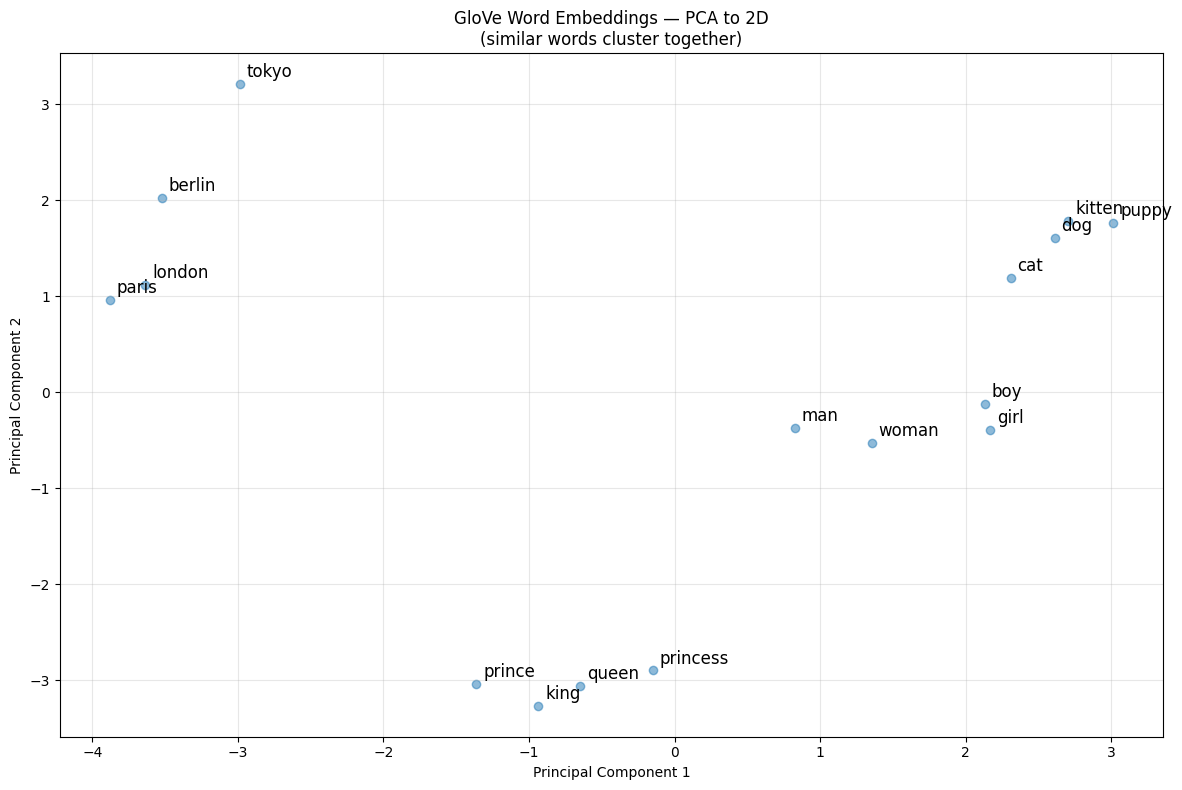

Saved to embeddings_pca.png


In [5]:
print("------ word similarity with Glove ---")
print("king <-> queen : ",glove.similarity("king","queen"))
print("king <-> dog : ",glove.similarity("king","dog"))
print("paris <-> london : ",glove.similarity("paris","london"))
print("python <-> java : ",glove.similarity("python","java"))

print("--- Most similar to king ----")
for word, score in glove.most_similar("kin",topn=5):
    print(f"{word:15s} {score:.4f}")

print("king-man+woman= ")
for word,score in glove.most_similar(positive=["king","woman"],negative=["man"],topn=3):
    print(f"{word:15s} {score:.4f}")

# Visiualize with PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

words_to_plot = [
    "king", "queen", "prince", "princess",
    "man",  "woman", "boy",    "girl",
    "dog",  "cat",   "puppy",  "kitten",
    "paris","london","berlin", "tokyo"
]

vectors=np.array([glove[word] for word in words_to_plot])
pca=PCA(n_components=2)
vecs_2d=pca.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(vecs_2d[:, 0], vecs_2d[:, 1], alpha=0.5)
for i, word in enumerate(words_to_plot):
    plt.annotate(word, vecs_2d[i], fontsize=12,
                 xytext=(5, 5), textcoords='offset points')
plt.title("GloVe Word Embeddings — PCA to 2D\n"
          "(similar words cluster together)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("embeddings_pca.png", dpi=150)
plt.show()
print("Saved to embeddings_pca.png")
